# 01 - EDA: CNEFE 2010

Exploração inicial dos dados do Cadastro Nacional de Endereços para Fins Estatísticos.

**81 milhões de linhas**  usamos DuckDB para consultar em disco sem carregar tudo na memória.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
CNEFE = "'../data/cnefe_2010/*.snappy.parquet'"

In [2]:
# Visão geral: schema e total de linhas
con.execute(f"DESCRIBE SELECT * FROM read_parquet({CNEFE}) LIMIT 1").df()

,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,seq,VARCHAR,YES,None,None,None
2,uf,VARCHAR,YES,None,None,None
3,munic,VARCHAR,YES,None,None,None
4,tipo,VARCHAR,YES,None,None,None
5,titulo,VARCHAR,YES,None,None,None
6,logradouro,VARCHAR,YES,None,None,None
7,numero,VARCHAR,YES,None,None,None
8,complemento,VARCHAR,YES,None,None,None
9,localidade,VARCHAR,YES,None,None,None


In [3]:
con.execute(f"SELECT COUNT(*) as total FROM read_parquet({CNEFE})").df()

,total
0,81550587


In [4]:
# Amostra das primeiras linhas
con.execute(f"SELECT * FROM read_parquet({CNEFE}) LIMIT 10").df()

,id,seq,uf,munic,tipo,titulo,logradouro,numero,complemento,localidade,cep,setor,situacao
0,355030811302994,11302994,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,486,NaN,VILA RICA,03911010,355030804000099,1
1,355030811302995,11302995,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,494,NaN,VILA RICA,03911010,355030804000099,1
2,355030811302996,11302996,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,498,TERREO,VILA RICA,03911010,355030804000099,1
3,355030811302997,11302997,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,506,FRENTE,VILA RICA,03911010,355030804000099,1
4,355030811302998,11302998,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,506,FUNDOS,VILA RICA,03911010,355030804000099,1
5,355030811302999,11302999,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,514,SOBRADO,VILA RICA,03911010,355030804000099,1
6,355030811303000,11303000,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,520,NaN,VILA RICA,03911010,355030804000099,1
7,355030811303001,11303001,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,528,FRENTE,VILA RICA,03911010,355030804000099,1
8,355030811303002,11303002,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,538,NaN,VILA RICA,03911010,355030804000099,1
9,355030811303003,11303003,35,50308,AVENIDA,ENGENHEIRO,PINTO MARTINS,540,NaN,VILA RICA,03911010,355030804000099,1


In [5]:
# Valores nulos por coluna
con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE id IS NULL) AS id_nulos,
        COUNT(*) FILTER (WHERE uf IS NULL) AS uf_nulos,
        COUNT(*) FILTER (WHERE munic IS NULL) AS munic_nulos,
        COUNT(*) FILTER (WHERE tipo IS NULL) AS tipo_nulos,
        COUNT(*) FILTER (WHERE logradouro IS NULL) AS logradouro_nulos,
        COUNT(*) FILTER (WHERE numero IS NULL) AS numero_nulos,
        COUNT(*) FILTER (WHERE cep IS NULL) AS cep_nulos,
        COUNT(*) FILTER (WHERE setor IS NULL) AS setor_nulos,
        COUNT(*) FILTER (WHERE situacao IS NULL) AS situacao_nulos
    FROM read_parquet({CNEFE})
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,id_nulos,uf_nulos,munic_nulos,tipo_nulos,logradouro_nulos,numero_nulos,cep_nulos,setor_nulos,situacao_nulos
0,0,0,0,0,0,0,4,4,0


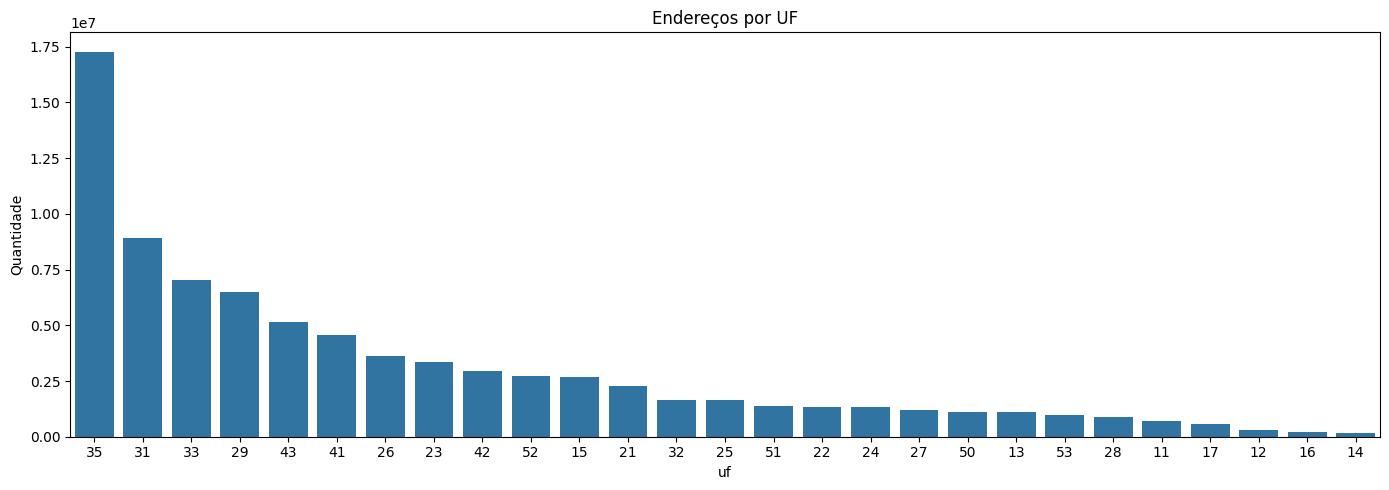

In [6]:
# Distribuição por UF
df_uf = con.execute(f"""
    SELECT uf, COUNT(*) as total
    FROM read_parquet({CNEFE})
    GROUP BY uf
    ORDER BY total DESC
""").df()

plt.figure(figsize=(14, 5))
sns.barplot(data=df_uf, x='uf', y='total')
plt.title('Endereços por UF')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.savefig('../outputs/figures/cnefe_por_uf.png', dpi=150)
plt.show()

In [7]:
# Distribuição por tipo de endereço
con.execute(f"""
    SELECT tipo, COUNT(*) as total
    FROM read_parquet({CNEFE})
    GROUP BY tipo
    ORDER BY total DESC
""").df()

,tipo,total
0,RUA,54229509
1,AVENIDA,8038351
2,ESTRADA,5465268
3,TRAVESSA,2412361
4,FAZENDA,1521614
...,...,...
304,PANTANO,1
305,PLATAFORMA,1
306,CHARCO,1
307,JARDINETE,1


In [8]:
# Distribuição por situação
con.execute(f"""
    SELECT situacao, COUNT(*) as total
    FROM read_parquet({CNEFE})
    GROUP BY situacao
    ORDER BY total DESC
""").df()

,situacao,total
0,1,66601014
1,2,14949573
